In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import matplotlib.dates as mdates
import os

from datetime import date
from dateutil.relativedelta import relativedelta

In [2]:
folder_path = 'store-sales-time-series-forecasting/'
datasets = {}

for file in os.listdir(folder_path):
    if(file.endswith('.csv')):
        name = os.path.splitext(file)[0]
        file_path = os.path.join(folder_path, file)
        datasets[name] = pd.read_csv(file_path)

In [3]:
for i in datasets.keys():
    print(f'<li>{i}</li>')

<li>holidays_events</li>
<li>oil</li>
<li>sample_submission</li>
<li>stores</li>
<li>test</li>
<li>train</li>
<li>transactions</li>


In [4]:
#funciton used to describe the different values in the columns
def describe_ds(df):
    for i in  df.columns:
        print(i)
        print(df[i].value_counts())
        print(" ")
        print(" ")
        print(" ")

In [5]:
df = datasets[list(datasets.keys())[5]]

It looks like we have the following datasets:
<ul>
    <li>holidays_events</li>
    <li>oil</li>
    <li>sample_submission</li>
    <li>stores</li>
    <li>test</li>
    <li>train</li>
    <li>transactions</li>
</ul>

First we inspec the holiday events, it includes 350 holidays with no missing dates. Using the dataset analysis we can see:
<ul>
    <li>there are 6 types of events with holiday being the most observed</li>
    <li>They are mostly distributed between national and local with a few regional</li>
    <li>We have a list of name of the events and cities where this applies. The city might apply</li>
    <li>We have most of them as transferred</li>
</ul>

Next we have the oil prices with missing values. even tho we cant identify the reason for these missing values, we can see the data prior to the missing value and after is not changing too drastically which means we can fill them backwards.

Third we have the sample submission, this can be ignored. 

Fourth we have the stores. This includes 54 stores with no missing values the columns we have are: 
<ul>
    <li>store_nbr</li>
    <li>city</li>
    <li>state</li>
    <li>type</li>
    <li>cluster: the most interesting one, showins us clusters from 1 to 17 with as many as 12 stores per cluster</li>
</ul>

5th we have the test dataset whcih is the dataset we want to forecast for, with the test data in set used for training purposes. both of them have the following columns id, date, store_nbr, family, onpromotion. The only difference here is that the training test set includes the sales column.
The dataset includes information on the categories and the total sales as well as how much as in promotion 

For the test dataset, the sales are betweeen 0 and 125K with the average close to 350 and the 50% around 11. The numbers are floating so is safe to asume the sales are in USD. on the other hand the on promo column includes rounded numbers betweem 0 and 800. I will assume this is the number of items in the section on sale.

The final dataset (transactions) include date, store_nbr and transactions. This looks like is the number of transactions per store per date in the training dataset. We will use this information to create a combined df that we can use for the model.


The plan then is:

<ul>
    <li>Join train with transactions</li>
</ul>


In [6]:
names_datasets = list(datasets.keys())

In [7]:
names_datasets

['holidays_events',
 'oil',
 'sample_submission',
 'stores',
 'test',
 'train',
 'transactions']

In [8]:
df1 = datasets[names_datasets[-2]]
df1['date'] = pd.to_datetime(df1['date'])

In [9]:
df2 = datasets[names_datasets[-1]]
df2['date'] = pd.to_datetime(df2['date'])

In [10]:
#join the transactions dataset to the train dataset 
df = pd.merge(df1, df2, on=['date', 'store_nbr'],how='left')

In [11]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,NaN
2,2,2013-01-01,1,BEAUTY,0.0,0,NaN
3,3,2013-01-01,1,BEVERAGES,0.0,0,NaN
4,4,2013-01-01,1,BOOKS,0.0,0,NaN


In [12]:
len(df[df['transactions'].isna()].date.unique())/len(df.date.unique())

0.9299287410926366

Considering that almost 93% of the dates have some sort of missing transactions. we will fill the missing transactions with 0 and likely will drop them as they might not bring value to the model

In [13]:
#fill nas with 0
df.transactions = df.transactions.fillna(0)

In [14]:
df1 = datasets[names_datasets[3]]

In [15]:
pd.pivot_table(df1, index='cluster', columns='type', values='store_nbr', aggfunc='count', fill_value=0)

type,A,B,C,D,E
cluster,,,,,
1,0,0,0,3,0
2,0,0,0,2,0
3,0,0,7,0,0
4,0,0,0,3,0
5,1,0,0,0,0
6,0,6,0,0,0
7,0,0,2,0,0
8,0,0,0,3,0
9,0,0,0,2,0


Considering that the same type can be in multiple clusters, is important to keep both.

In [19]:
#join the transactions dataset to the train dataset 
df = pd.merge(df, df1, on=['store_nbr'],how='left')

In [20]:
df1 = datasets[names_datasets[1]]

In [21]:
#conver to datetime
df1.date = pd.to_datetime(df1.date)

In [26]:
#join the oil dataset to the main dataset
df = pd.merge(df, df1, on=['date'],how='left')

In [27]:
#fill nas with future values
df['dcoilwtico']=df['dcoilwtico'].bfill()

In [28]:
df1 = datasets[names_datasets[0]]

In [31]:
#conver to datetime
df1.date = pd.to_datetime(df1.date)

Before we join the holiday dataset, we need to udnerstand that the transferred column indicates A holiday that is transferred officially falls on that calendar day, but was moved to another date by the government. A transferred day is more like a normal day than a holiday. Because of this, we will only add the actual (non transferred holidays)

In [33]:
#join the holiday dataset to the main dataset
df = pd.merge(df, df1[df1['transferred']==False], on=['date'],how='left',suffixes=('_store', '_holiday'))

In [34]:
df.isna().sum()

id                    0
date                  0
store_nbr             0
family                0
sales                 0
onpromotion           0
transactions          0
city                  0
state                 0
type_store            0
cluster               0
dcoilwtico            0
type_holiday    2567862
locale          2567862
locale_name     2567862
description     2567862
transferred     2567862
dtype: int64

it looks like the NA holidays are when there is no holidays and the non nas is when there was a holiday. in order to maintain a usable dataset we are fill the type and locale to "no holiday" and drop the type, locale, description and transferred.

In [55]:
#create the column for is holiday 
df['is_holiday'] = (~df['type_holiday'].isna()).astype(int)
#fill out the NA with "Ecuador" for locale_name
df['locale_name'] = df['locale_name'].fillna('Ecuador')

In [68]:
#drop the columns we will not use
df = df.drop(columns=['type_holiday', 'locale', 'locale_name', 'description', 'transferred'])

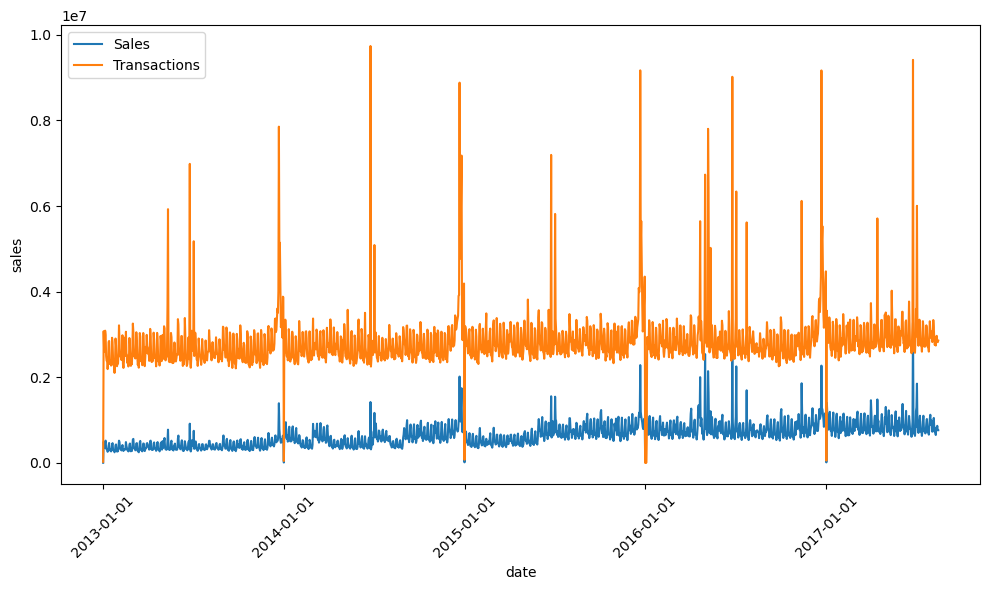

In [86]:
fig, ax = plt.subplots(figsize=(10, 6))
df1 = df[['date', 'sales', 'transactions']].groupby('date').sum()
sns.lineplot(df1['sales'], ax=ax, label = 'Sales')
sns.lineplot(df1['transactions'], ax=ax , label = 'Transactions')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

AS expected, the number of sales is lower than the number of transactions in most cases. this due to the fact that many transactions could be for far less than 1 dollar. We will forecast the number of sales after all 

In [92]:
df1 = df1.drop(columns = 'transactions')

In [94]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,transactions,city,state,type_store,cluster,dcoilwtico,is_holiday
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,0.0,Quito,Pichincha,D,13,93.14,1
1,1,2013-01-01,1,BABY CARE,0.0,0,0.0,Quito,Pichincha,D,13,93.14,1
2,2,2013-01-01,1,BEAUTY,0.0,0,0.0,Quito,Pichincha,D,13,93.14,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,0.0,Quito,Pichincha,D,13,93.14,1
4,4,2013-01-01,1,BOOKS,0.0,0,0.0,Quito,Pichincha,D,13,93.14,1


Identify if there is a seasonality first:

In [ ]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(df['#Passengers'])

Considering the above, it looks like there is a seasonality that repeats every 12 lags or so. Lets identify the ACF and PACF:

In [ ]:
import statsmodels.api as sm
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df['#Passengers'], lags=12, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['#Passengers'], lags=12, ax=ax2)

ACF plots show the correlation between a time series and a lagged version of itself, decreasing exponentially. 

PACF plots show the correlation between a time series and a lagged version of itself after removing the effects of intervening observations. The PACF graph is abrupt after 2 views.

the next thing we need to do es identify the decomposition parts:

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['#Passengers'], period=12)  
fig = plt.figure()  
fig = decomposition.plot()  
fig.set_size_inches(15, 8)

In [ ]:
from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):

    #Determing rolling statistics
    rolmean = timeseries.rolling(window=52).mean()
    rolstd = timeseries.rolling(window=52).std()

    #Plot rolling statistics:
    fig = plt.figure(figsize=(12, 8))
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show()
    
    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

In [ ]:
test_stationarity(df['#Passengers'])

Since the results are showing the data is not stationary, we need to make it stationary by either differencing, log, square, cube root or proportional change

In [ ]:
df_firstdiff = df['#Passengers'].diff(12) #taking the first difference
test_stationarity(df_firstdiff.dropna()) #testing the data to identify if it is stationary now

Now that the data is stationary, we can identify the p, d and q values to use for ARIMa. in order to do so we are going to use auto ARIMA

In [ ]:
df['month_index']= df.index.month

In [ ]:
import pmdarima as pmd

model=pmd.auto_arima(df['#Passengers'], exogenous = df['month_index'], 
                        start_p=1, start_q=1, test='adf',
                        max_p=3, max_q=3, m=12,
                        start_P=0, seasonal=True,
                        d=None, D=1, trace=True, error_action='ignore',
                        suppress_warnings=True, stepwise=True)

In [ ]:
display(model.summary())
model.plot_diagnostics(figsize=(12,6));

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
mod=SARIMAX(df['#Passengers'],order=(0,1,1),seasonal_order=(2,1,0,12))
sarima = mod.fit()
predicted=sarima.predict();predicted

We are looking for: 
<ul>
    <li>P > |z| (p-value) < 0.05</li>
    <li>Prob(Q) > 0.05 --> residues are white noise</li>
    <li>Prob(JB) > 0.05 residues normally distributed</li>
    <li>Prob(H) > 0.05 variance of residuals is constant over time</li>
</ul>


In [ ]:
df['pred'] = predicted

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(df, x='Month', y='#Passengers', ax=ax, color='blue')
sns.lineplot(df, x='Month', y='pred', ax=ax, color='red')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Now, for future forecast. we will create the funciton that takes the trained model and generates 2 years (24 months) of forecast:

In [ ]:
def sarimax_forecast(SARIMAX_model, periods=24):
    # Forecast
    n_periods = periods

    forecast_df = pd.DataFrame({"month_index": pd.date_range(df.index[-1], periods=n_periods, freq='MS').month},
                               index=pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=n_periods, freq='MS'))

    fcst = SARIMAX_model.get_forecast(steps=n_periods,
                                            exog=forecast_df['month_index'])
    fitted = fcst.predicted_mean
    confint = fcst.conf_int(alpha = 0.05)

    # make series for plotting purpose
    fitted_series = pd.Series(fitted, index=fitted.index)
    lower_series = pd.Series(confint.iloc[:, 0], index=confint.index)
    upper_series = pd.Series(confint.iloc[:, 1], index=confint.index)

    # Plot
    plt.figure(figsize=(15, 7))
    plt.plot(df["#Passengers"], color='#1f76b4')
    plt.plot(fitted_series, color='darkgreen')
    plt.fill_between(lower_series.index,
                     lower_series,
                     upper_series,
                     color='k', alpha=.15)

    plt.title("SARIMAX - Forecast of Airline Passengers")
    plt.show()

In [ ]:
sarimax_forecast(sarima, 24)